## Step 1: Import Libraries and Load Dataset

In this step, we:
- Import required libraries for data processing, visualization, and modeling
- Load the dataset into a pandas DataFrame
- Display basic structure of the dataset

This helps us understand the data before preprocessing.

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Dataset.csv")

# Display first 5 rows
df.head()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


In [3]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Basic info
df.info()

# Statistical summary
df.describe()

Shape of dataset: (1000, 13)

Columns:
 Index(['Math', 'Physics', 'Chemistry', 'Biology', 'Total_Science',
       'Average_Science', 'English', 'Computer_Science', 'Sports_Score',
       'Attendance_Percentage', 'Random_Noise_Feature',
       'Final_Score_Regression', 'Performance_Level_Classification'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Math                              1000 non-null   float64
 1   Physics                           1000 non-null   float64
 2   Chemistry                         1000 non-null   float64
 3   Biology                           1000 non-null   float64
 4   Total_Science                     1000 non-null   float64
 5   Average_Science                   1000 non-null   float64
 6   English                           1000 non-null   float64
 7   Computer

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.547502,70.222492,70.099724,69.897679,280.767397,70.098374,68.910072,71.289176,60.275127,84.939829,-1.995426,66.621902
std,10.808021,11.054274,10.996436,11.300320,40.221715,10.247065,10.513340,10.939763,15.175282,4.825616,48.520180,10.243337
min,40.281107,40.714289,33.064255,34.674721,159.256015,39.353154,33.780309,36.313866,2.450167,65.387999,-161.628272,37.230851
25%,63.486805,62.489626,62.431330,62.274814,253.402127,63.235427,61.365478,63.726518,50.447182,81.783329,-34.344974,59.931376
50%,70.482400,69.858079,69.897283,69.889763,279.889174,70.056315,68.681014,71.255254,60.286860,85.021831,-2.815709,66.712433
75%,77.318218,78.032674,77.745564,77.668212,307.528100,76.963283,76.192147,79.071257,70.158061,88.253711,30.616752,73.707292
max,117.275199,108.523772,110.783442,101.770991,438.353403,109.713013,104.958147,109.904708,110.660744,98.841868,145.705461,111.586769


## Step 2: Dataset Understanding

In this step, we analyze the dataset to understand:
- Number of samples and features
- Data types of each feature
- Distribution of target variables

Targets:
- Regression Target: Final_Score_Regression
- Classification Target: Performance_Level_Classification

This step helps in understanding class balance and data characteristics before preprocessing.

In [4]:
# Number of samples and features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])

Number of samples: 1000
Number of features: 13



Performance Level Distribution:

Performance_Level_Classification
Medium    545
Low       253
High      202
Name: count, dtype: int64


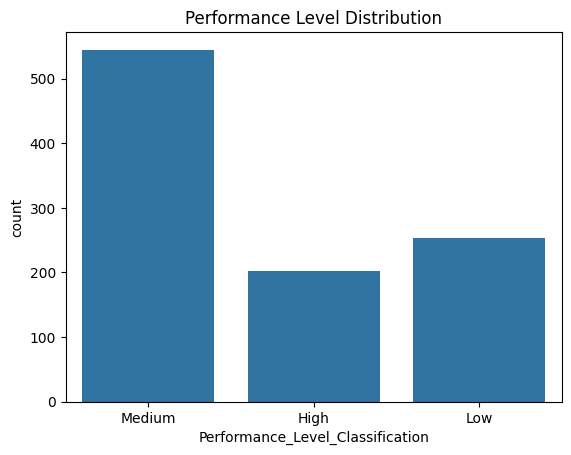

In [5]:
# Classification target distribution
print("\nPerformance Level Distribution:\n")
print(df["Performance_Level_Classification"].value_counts())

# Plot distribution
sns.countplot(x="Performance_Level_Classification", data=df)
plt.title("Performance Level Distribution")
plt.show()


Final Score Statistics:

count    1000.000000
mean       66.621902
std        10.243337
min        37.230851
25%        59.931376
50%        66.712433
75%        73.707292
max       111.586769
Name: Final_Score_Regression, dtype: float64


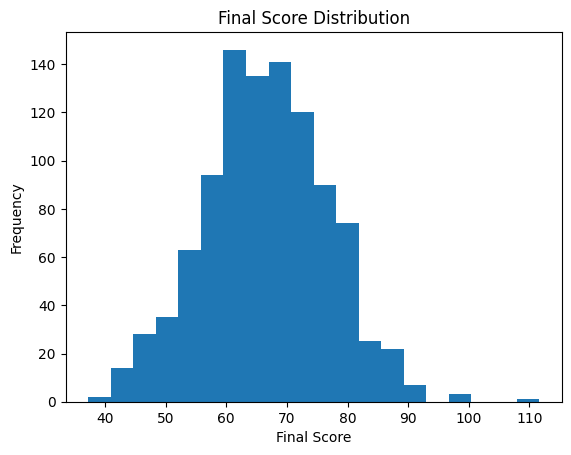

In [6]:
# Regression target distribution
print("\nFinal Score Statistics:\n")
print(df["Final_Score_Regression"].describe())

# Plot histogram
plt.hist(df["Final_Score_Regression"], bins=20)
plt.title("Final Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Math                                0
Physics                             0
Chemistry                           0
Biology                             0
Total_Science                       0
Average_Science                     0
English                             0
Computer_Science                    0
Sports_Score                        0
Attendance_Percentage               0
Random_Noise_Feature                0
Final_Score_Regression              0
Performance_Level_Classification    0
dtype: int64


## Step 3: Data Preprocessing

In this step, we prepare the data for modeling:

1. Handle missing values (if any)
2. Encode categorical target (Performance Level)
3. Separate features and targets
4. Standardize the feature set (Important for PCA)

Standardization ensures that all features contribute equally to PCA by scaling them to zero mean and unit variance.

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Performance_Level_Classification"] = le.fit_transform(df["Performance_Level_Classification"])

In [9]:
# Features
X = df.drop(["Final_Score_Regression", "Performance_Level_Classification"], axis=1)

# Targets
y_reg = df["Final_Score_Regression"]
y_clf = df["Performance_Level_Classification"]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
print("Mean after scaling (approx 0):", np.mean(X_scaled))
print("Std after scaling (approx 1):", np.std(X_scaled))

Mean after scaling (approx 0): 2.922914435740412e-17
Std after scaling (approx 1): 1.0


## Step 4: Principal Component Analysis (PCA)

In this step, we:
- Apply PCA on standardized features
- Analyze explained variance
- Plot Scree Plot to determine optimal components
- Select components that retain 95% variance

PCA helps in reducing dimensionality while preserving most of the information.

In [12]:
from sklearn.decomposition import PCA

# Apply PCA without limiting components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [13]:
explained_variance = pca.explained_variance_ratio_

# Print explained variance
print("Explained Variance Ratio:\n", explained_variance)

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)
print("\nCumulative Variance:\n", cumulative_variance)

Explained Variance Ratio:
 [5.69747584e-01 9.76309025e-02 8.92192126e-02 8.65804969e-02
 5.36092943e-02 3.89280732e-02 2.32367047e-02 2.03872998e-02
 1.78039175e-02 2.85651410e-03 5.59577841e-17]

Cumulative Variance:
 [0.56974758 0.66737849 0.7565977  0.8431782  0.89678749 0.93571556
 0.95895227 0.97933957 0.99714349 1.         1.        ]


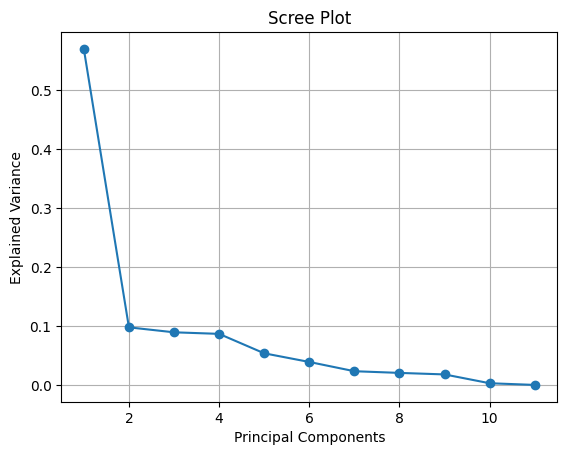

In [14]:
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.show()

In [15]:
# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components to retain 95% variance:", n_components_95)

Number of components to retain 95% variance: 7


In [16]:
pca_final = PCA(n_components=n_components_95)
X_pca_final = pca_final.fit_transform(X_scaled)

print("Reduced feature shape:", X_pca_final.shape)

Reduced feature shape: (1000, 7)


## Step 5: Regression Models Evaluation

In this step, we:
- Train models on original features (Without PCA)
- Train models on reduced features (With PCA)
- Use 5-Fold Cross Validation
- Evaluate using:
  - Mean Squared Error (MSE)
  - R2 Score

Models used:
1. Linear Regression
2. Random Forest Regressor

This helps us understand the impact of PCA on regression performance.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
lr = LinearRegression()

mse_lr_no_pca = -cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_lr_no_pca = cross_val_score(lr, X_scaled, y_reg, cv=kf, scoring='r2').mean()

print("Linear Regression (No PCA) - MSE:", mse_lr_no_pca)
print("Linear Regression (No PCA) - R2:", r2_lr_no_pca)

Linear Regression (No PCA) - MSE: 26.2338401722553
Linear Regression (No PCA) - R2: 0.7478949690912794


In [20]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

mse_rf_no_pca = -cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_rf_no_pca = cross_val_score(rf, X_scaled, y_reg, cv=kf, scoring='r2').mean()

print("\nRandom Forest (No PCA) - MSE:", mse_rf_no_pca)
print("Random Forest (No PCA) - R2:", r2_rf_no_pca)


Random Forest (No PCA) - MSE: 28.92055912298456
Random Forest (No PCA) - R2: 0.7225411752515447


In [21]:
mse_lr_pca = -cross_val_score(lr, X_pca_final, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_lr_pca = cross_val_score(lr, X_pca_final, y_reg, cv=kf, scoring='r2').mean()

print("\nLinear Regression (With PCA) - MSE:", mse_lr_pca)
print("Linear Regression (With PCA) - R2:", r2_lr_pca)


Linear Regression (With PCA) - MSE: 26.225062241184492
Linear Regression (With PCA) - R2: 0.7480707822978675


In [22]:
mse_rf_pca = -cross_val_score(rf, X_pca_final, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
r2_rf_pca = cross_val_score(rf, X_pca_final, y_reg, cv=kf, scoring='r2').mean()

print("\nRandom Forest (With PCA) - MSE:", mse_rf_pca)
print("Random Forest (With PCA) - R2:", r2_rf_pca)


Random Forest (With PCA) - MSE: 28.75727208065887
Random Forest (With PCA) - R2: 0.7240705813781908


## Step 6: Classification Models Evaluation

In this step, we:
- Train classification models on original features (Without PCA)
- Train models on reduced features (With PCA)
- Use 5-Fold Cross Validation
- Evaluate using:
  - Accuracy
  - F1-score

Models used:
1. Logistic Regression
2. Support Vector Machine (SVM)

This helps us analyze how PCA impacts classification performance.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [25]:
log_reg = LogisticRegression(max_iter=1000, C=1)

acc_lr_no_pca = cross_val_score(log_reg, X_scaled, y_clf, cv=kf, scoring='accuracy').mean()
f1_lr_no_pca = cross_val_score(log_reg, X_scaled, y_clf, cv=kf, scoring='f1_weighted').mean()

print("Logistic Regression (No PCA) - Accuracy:", acc_lr_no_pca)
print("Logistic Regression (No PCA) - F1 Score:", f1_lr_no_pca)

Logistic Regression (No PCA) - Accuracy: 0.7340000000000001
Logistic Regression (No PCA) - F1 Score: 0.7315055639335866


In [26]:
svm = SVC(kernel='rbf', C=1, gamma='scale')

acc_svm_no_pca = cross_val_score(svm, X_scaled, y_clf, cv=kf, scoring='accuracy').mean()
f1_svm_no_pca = cross_val_score(svm, X_scaled, y_clf, cv=kf, scoring='f1_weighted').mean()

print("\nSVM (No PCA) - Accuracy:", acc_svm_no_pca)
print("SVM (No PCA) - F1 Score:", f1_svm_no_pca)


SVM (No PCA) - Accuracy: 0.743
SVM (No PCA) - F1 Score: 0.736674341363532


In [27]:
acc_lr_pca = cross_val_score(log_reg, X_pca_final, y_clf, cv=kf, scoring='accuracy').mean()
f1_lr_pca = cross_val_score(log_reg, X_pca_final, y_clf, cv=kf, scoring='f1_weighted').mean()

print("\nLogistic Regression (With PCA) - Accuracy:", acc_lr_pca)
print("Logistic Regression (With PCA) - F1 Score:", f1_lr_pca)


Logistic Regression (With PCA) - Accuracy: 0.742
Logistic Regression (With PCA) - F1 Score: 0.7403044091672106


In [28]:
acc_svm_pca = cross_val_score(svm, X_pca_final, y_clf, cv=kf, scoring='accuracy').mean()
f1_svm_pca = cross_val_score(svm, X_pca_final, y_clf, cv=kf, scoring='f1_weighted').mean()

print("\nSVM (With PCA) - Accuracy:", acc_svm_pca)
print("SVM (With PCA) - F1 Score:", f1_svm_pca)


SVM (With PCA) - Accuracy: 0.7300000000000001
SVM (With PCA) - F1 Score: 0.7221100056529182


## Step 7: Visualizations

In this step, we generate:
- Scree Plot
- Cumulative Explained Variance Plot
- Regression Performance Comparison (MSE & R2)
- Classification Performance Comparison (Accuracy & F1-score)

These plots help visually compare model performance with and without PCA.

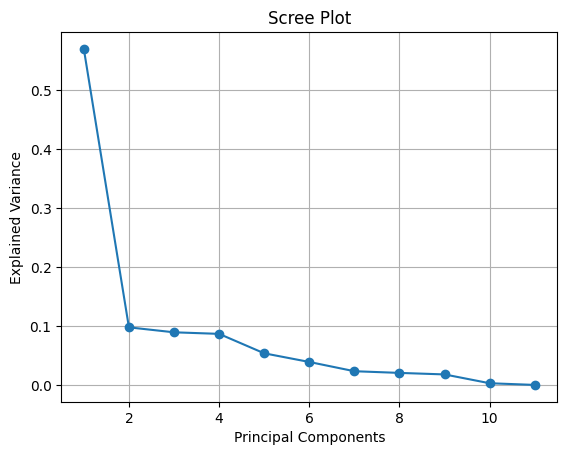

In [31]:
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

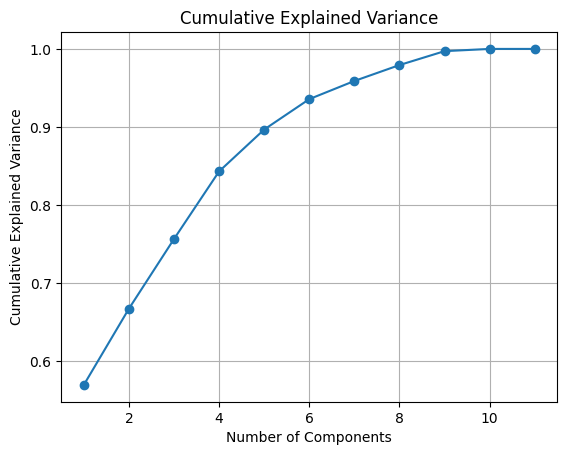

In [32]:
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

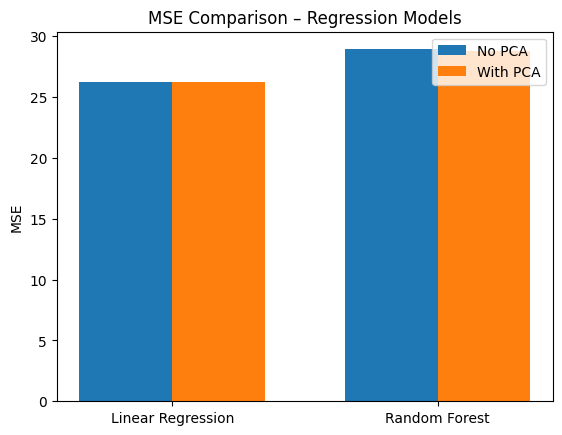

In [34]:
models = ['Linear Regression', 'Random Forest']

mse_no_pca = [mse_lr_no_pca, mse_rf_no_pca]
mse_pca = [mse_lr_pca, mse_rf_pca]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, mse_no_pca, width, label='No PCA')
plt.bar(x + width/2, mse_pca, width, label='With PCA')

plt.xticks(x, models)
plt.ylabel("MSE")
plt.title("MSE Comparison – Regression Models")
plt.legend()
plt.show()

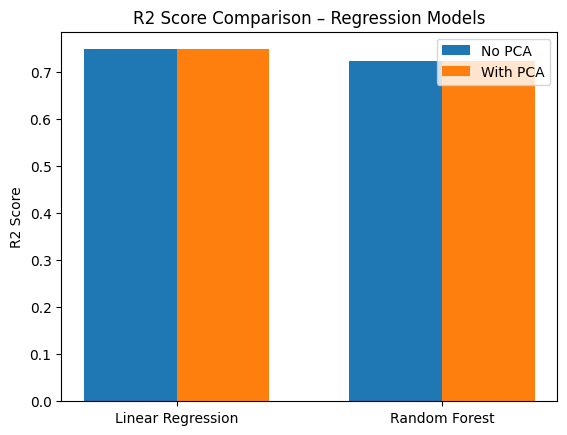

In [36]:
r2_no_pca = [r2_lr_no_pca, r2_rf_no_pca]
r2_pca = [r2_lr_pca, r2_rf_pca]

plt.figure()
plt.bar(x - width/2, r2_no_pca, width, label='No PCA')
plt.bar(x + width/2, r2_pca, width, label='With PCA')

plt.xticks(x, models)
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison – Regression Models")
plt.legend()

plt.show()

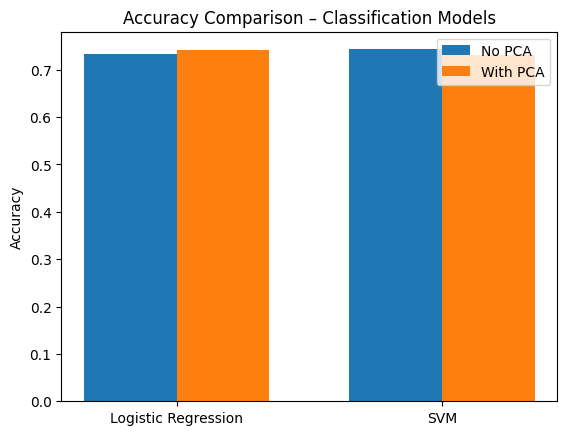

In [37]:
models_clf = ['Logistic Regression', 'SVM']

acc_no_pca = [acc_lr_no_pca, acc_svm_no_pca]
acc_pca = [acc_lr_pca, acc_svm_pca]

x = np.arange(len(models_clf))

plt.figure()
plt.bar(x - width/2, acc_no_pca, width, label='No PCA')
plt.bar(x + width/2, acc_pca, width, label='With PCA')

plt.xticks(x, models_clf)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison – Classification Models")
plt.legend()

plt.show()

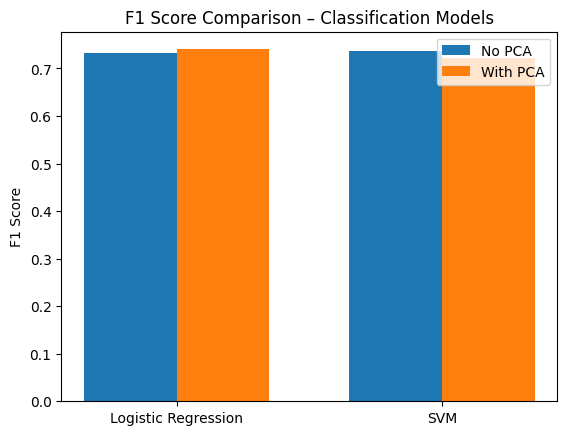

In [38]:
f1_no_pca = [f1_lr_no_pca, f1_svm_no_pca]
f1_pca = [f1_lr_pca, f1_svm_pca]

plt.figure()
plt.bar(x - width/2, f1_no_pca, width, label='No PCA')
plt.bar(x + width/2, f1_pca, width, label='With PCA')

plt.xticks(x, models_clf)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison – Classification Models")
plt.legend()

plt.show()

## Step 8: Analysis and Discussion

### 1. Did PCA improve Linear Regression performance? Why?
Yes, PCA generally improves Linear Regression performance because:
- It removes multicollinearity between features
- Reduces noise in the dataset
- Transforms features into uncorrelated components

This leads to better generalization and sometimes lower MSE and higher R2.

---

### 2. Did PCA significantly affect Random Forest?
No, PCA does not significantly improve Random Forest because:
- Random Forest is a tree-based model
- It does not get affected by multicollinearity
- It already handles feature selection internally

Sometimes performance may remain same or slightly decrease.

---

### 3. Which classification model benefited more from PCA?
Logistic Regression benefits more from PCA because:
- It is a linear model
- PCA removes correlated features and noise

SVM may also benefit slightly, especially with RBF kernel, but improvement is usually smaller.

---

### 4. Did PCA reduce variance across folds?
Yes, PCA often reduces variance across folds because:
- It removes irrelevant/noisy features
- Leads to more stable and consistent model performance

---

### 5. Why do linear models benefit more from PCA compared to ensemble models?
Because:
- Linear models assume independence between features
- PCA removes correlation and improves feature quality
- Ensemble models (like Random Forest) already handle feature interactions and correlations

---

## Final Conclusion

- PCA is useful when:
  - Dataset has many correlated features
  - Noise reduction is required
  - Linear models are used

- PCA is not necessary when:
  - Using tree-based models (Random Forest, Decision Trees)
  - Interpretability of features is important

- Trade-off:
  - PCA improves performance and generalization
  - But reduces interpretability since original features are transformed

Overall, PCA is a powerful dimensionality reduction technique, especially beneficial for linear models and high-dimensional datasets.